In [1]:
#Veri seti Beyaz Saray ve önde gelen araştırma grupları tarafından oluşturulan Covid-19 açık kaynak veri setidir. CORD-19 veri seti, mevcut olan en kapsamlı koronavirüs literatür koleksiyonunu temsil ediyor. Koronavirüs literatüründeki hızlı değişimlere bilim insanlarının ayak uydurmaları zorluklara neden olmaktadır. Bu nedenle tıp camiasının yüksek öncelikli bilimsel sorulara yanıtlar geliştirmesine yardımcı olabilecek metin ve veri madenciliği araçları geliştirmesi amaçlanmaktadır.

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

data_org = pd.read_csv("metadata.csv", on_bad_lines='skip', engine='python')  # read data

df = data_org.copy()

df.head().T

,0,1,2,3,4
cord_uid,ug7v899j,02tnwd4m,ejv2xln0,2b73a28n,9785vg6d
sha,d1aafb70c066a2068b02786f8929fd9c900897fb,6b0567729c2143a66d737eb0a2f63f2dce2e5a7d,06ced00a5fc04215949aa72528f2eeaae1d58927,348055649b6b8cf2b9a376498df9bf41f7123605,5f48792a5fa08bed9f56016f4981ae2ca6031b32
source_x,PMC,PMC,PMC,PMC,PMC
title,Clinical features of culture-proven Mycoplasma...,Nitric oxide: a pro-inflammatory mediator in l...,Surfactant protein-D and pulmonary host defense,Role of endothelin-1 in lung disease,Gene expression in epithelial cells in respons...
doi,10.1186/1471-2334-1-6,10.1186/rr14,10.1186/rr19,10.1186/rr44,10.1186/rr61
pmcid,PMC35282,PMC59543,PMC59549,PMC59574,PMC59580
pubmed_id,11472636,11667967,11667972,11686871,11686888
license,no-cc,no-cc,no-cc,no-cc,no-cc
abstract,OBJECTIVE: This retrospective chart review des...,Inflammatory diseases of the respiratory tract...,Surfactant protein-D (SP-D) participates in th...,Endothelin-1 (ET-1) is a 21 amino acid peptide...,Respiratory syncytial virus (RSV) and pneumoni...
publish_time,2001-07-04,2000-08-15,2000-08-25,2001-02-22,2001-05-11


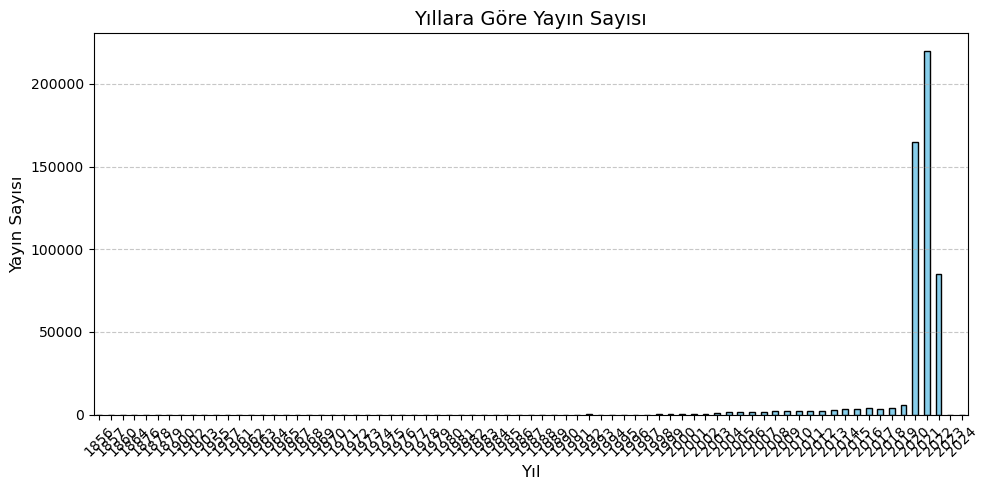

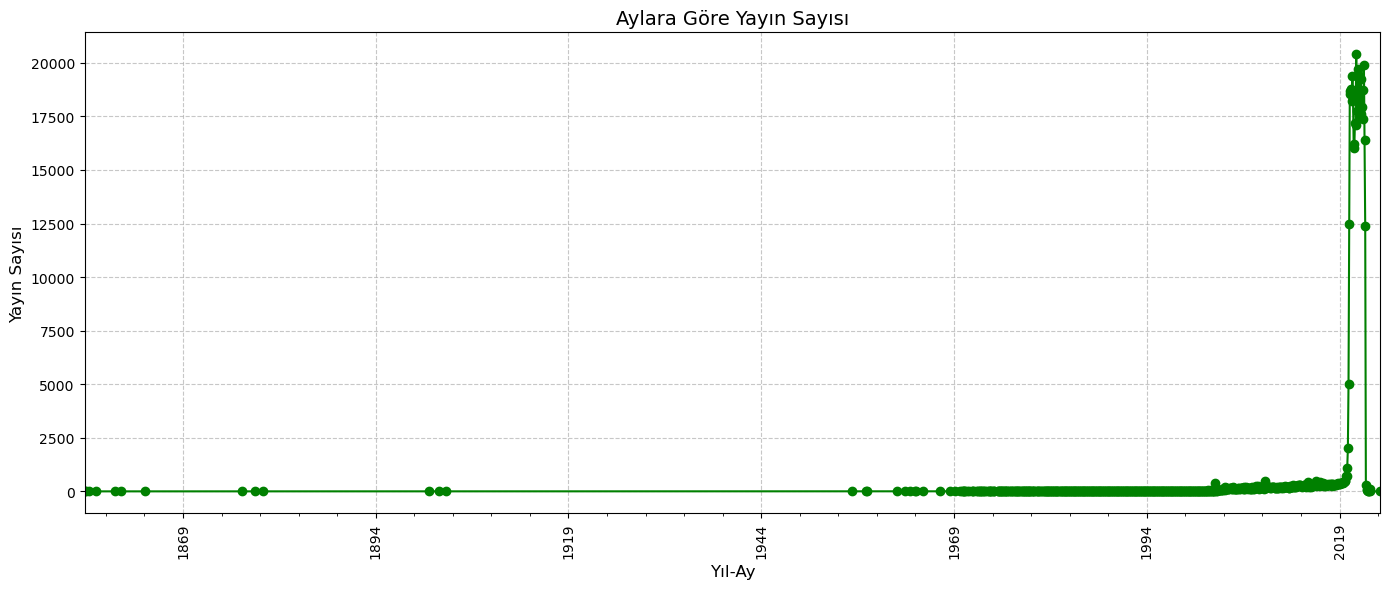

In [2]:
# COVID-19 literatürüne katkı sağlayan yayınların sayısı zaman içinde nasıl değişti?

df['publish_time'] = pd.to_datetime(df['publish_time'], errors='coerce') # convert publish_time to datetime format
df = df[df['publish_time'].notna()] # filter empty values


# Yıllık Yayın Sayısı Grafiği

yearly_counts = df['publish_time'].dt.year.value_counts().sort_index()

plt.figure(figsize=(10, 5))
yearly_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Yıllara Göre Yayın Sayısı', fontsize=14)
plt.xlabel('Yıl', fontsize=12)
plt.ylabel('Yayın Sayısı', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



# Aylık Yayın Sayısı Grafiği
monthly_counts = df['publish_time'].dt.to_period('M').value_counts().sort_index()

plt.figure(figsize=(14, 6))
monthly_counts.plot(kind='line', marker='o', color='green')
plt.title('Aylara Göre Yayın Sayısı', fontsize=14)
plt.xlabel('Yıl-Ay', fontsize=12)
plt.ylabel('Yayın Sayısı', fontsize=12)
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

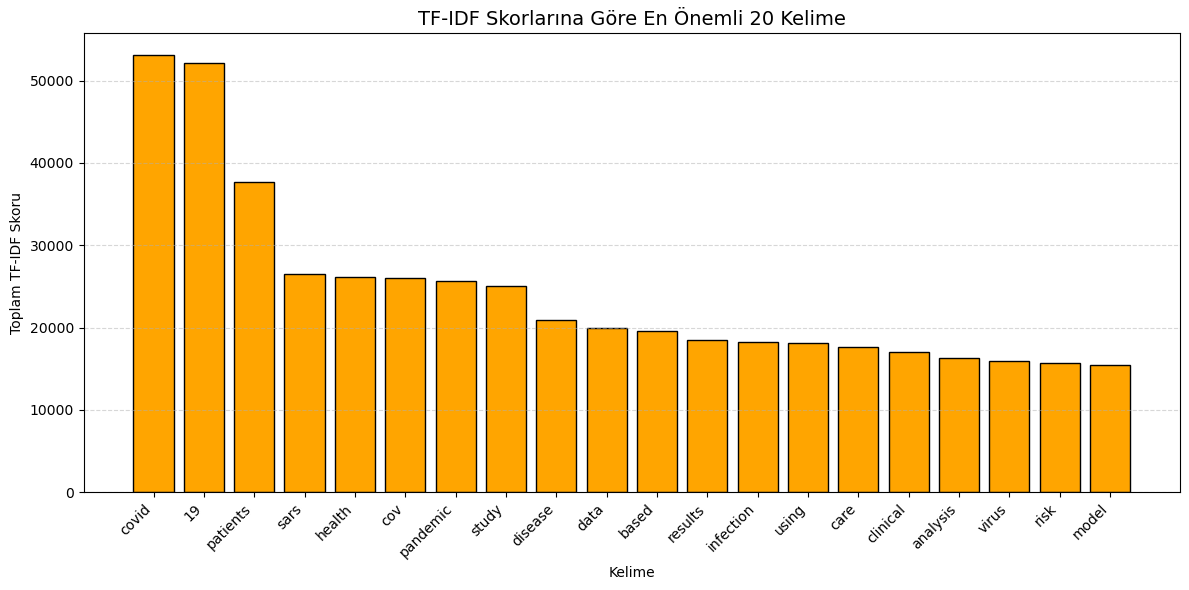

In [3]:
# Makalelerde en sık geçen terimler

df = df[df['abstract'].notna() & df['title'].notna()]  # filter missing values abstract and title

df['text'] = df['title'] + ' ' + df['abstract'] # create new value Text by combining title and abstract

vectorizer = TfidfVectorizer(stop_words='english', max_features=100) # convert text to vectoral format and remove meaningless words
X = vectorizer.fit_transform(df['text'])

tfidf_scores = dict(zip(vectorizer.get_feature_names_out(), X.sum(axis=0).A1))

top_words = dict(sorted(tfidf_scores.items(), key=lambda x: x[1], reverse=True)[:20]) # get max 20 words

plt.figure(figsize=(12, 6))
plt.bar(top_words.keys(), top_words.values(), color='orange', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.title("TF-IDF Skorlarına Göre En Önemli 20 Kelime", fontsize=14)
plt.xlabel("Kelime")
plt.ylabel("Toplam TF-IDF Skoru")
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

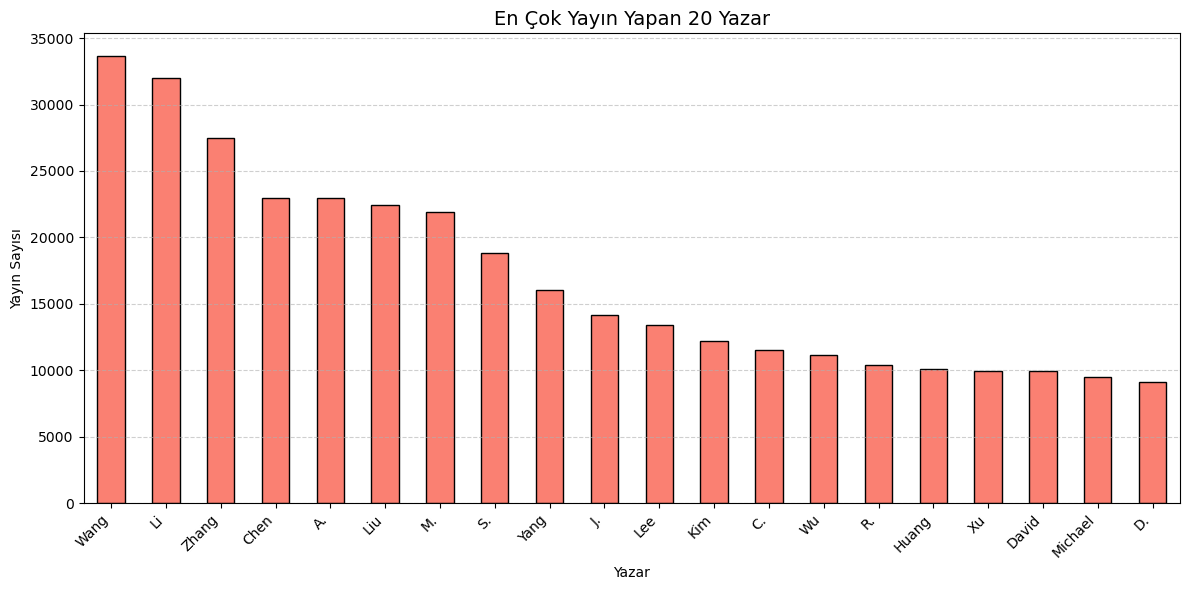

In [4]:
# En çok yazısı olan yazarlar

df_authors = df[df['authors'].notna()]  #filter missing values authors

all_authors = df_authors['authors'].str.split(';|,')  # split ; and , 

flat_authors = pd.Series([author.strip() for sublist in all_authors for author in sublist if author.strip() != ''])

top_authors = flat_authors.value_counts().head(20) # get 20 authors


plt.figure(figsize=(12, 6))
top_authors.plot(kind='bar', color='salmon', edgecolor='black')
plt.title('En Çok Yayın Yapan 20 Yazar', fontsize=14)
plt.xlabel('Yazar')
plt.ylabel('Yayın Sayısı')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()



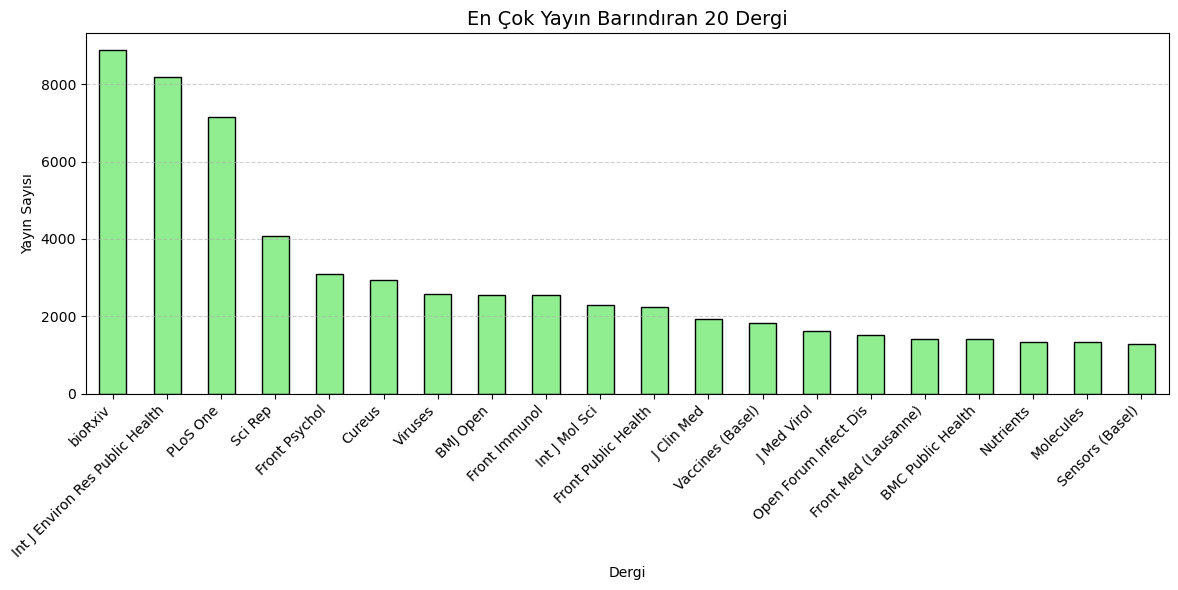

In [5]:
# En çok yayın yapan dergiler 

df_journals = df[df['journal'].notna()]  #filter missing values journal

top_journals = df_journals['journal'].value_counts().head(20)  # get 20 journal

plt.figure(figsize=(12, 6))
top_journals.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('En Çok Yayın Barındıran 20 Dergi', fontsize=14)
plt.xlabel('Dergi')
plt.ylabel('Yayın Sayısı')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

Eksik Değer Sayıları:
mag_id              415488
who_covidence_id    414492
arxiv_id            401242
pmc_json_files      145103
pmcid               106162
pdf_json_files       91445
sha                  91445
pubmed_id            80695
s2_id                53989
journal              35193
doi                  15481
authors               2104
dtype: int64


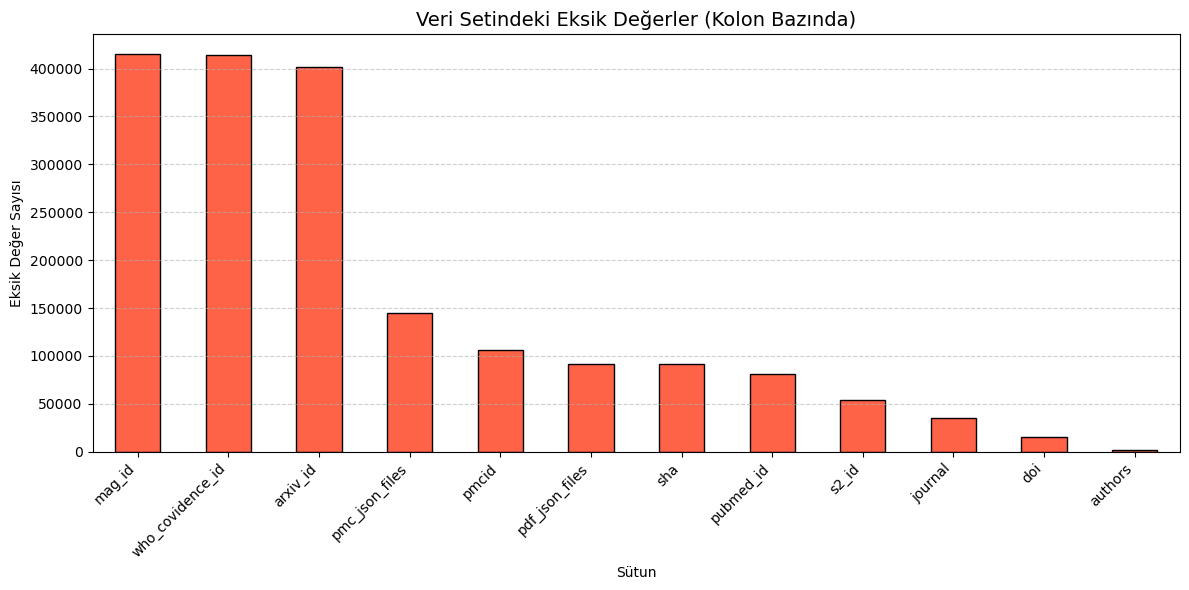

In [6]:
# Eksik Değer Analizi

missing_counts = df.isna().sum() # calculate missing values each cell

missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False) # get missing values


print("Eksik Değer Sayıları:")
print(missing_counts)


plt.figure(figsize=(12, 6))
missing_counts.plot(kind='bar', color='tomato', edgecolor='black')
plt.title('Veri Setindeki Eksik Değerler (Kolon Bazında)', fontsize=14)
plt.xlabel('Sütun')
plt.ylabel('Eksik Değer Sayısı')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

